# [LAB-06] 4. Histogram

## #01. 준비작업

### 1. 라이브러리 참조

In [2]:
from jussam import load_data
from helper import *
import seaborn as sb
import numpy as np

### 2. 데이터 가져오기

In [3]:
origin = load_data('employee_data_40')
origin.head()

📚 어느 기업의 직원 40명을 대상으로 성별과 결혼상태, 나이, 최종학력, 월수입을 조사한 가상의 데이터(인덱스, 메타데이터 없음)


,성별,결혼상태,나이,최종학력,월수입
0,남자,기혼,21,대학교,60
1,남자,기혼,22,대학원,100
2,남자,기혼,33,대학교,200
3,여자,미혼,33,대학교,120
4,남자,미혼,28,대학교,70


## #02. Histogram 시각화 하기

### 기본 사용 방법

- `x`축에 연속형 데이터를 지정, `y`축은 데이터의 수로 자동 설정됨
  - 패턴1(자동인식 패턴)의 경우 `x`축으로 지정됨
  - 패턴2(개별 데이터 직접 지정)의 경우 `x`파라미터만 설정
  - 패턴3(DataFrame + 컬럼명)의 경우 `data`와 `x`파라미터만 설정

### 1. 기본 사용 방법

- 구간이 자동으로 계산됨
  - x축 좌표가 임의로 설정되기 때문에 구간을 파악하기 어렵다.

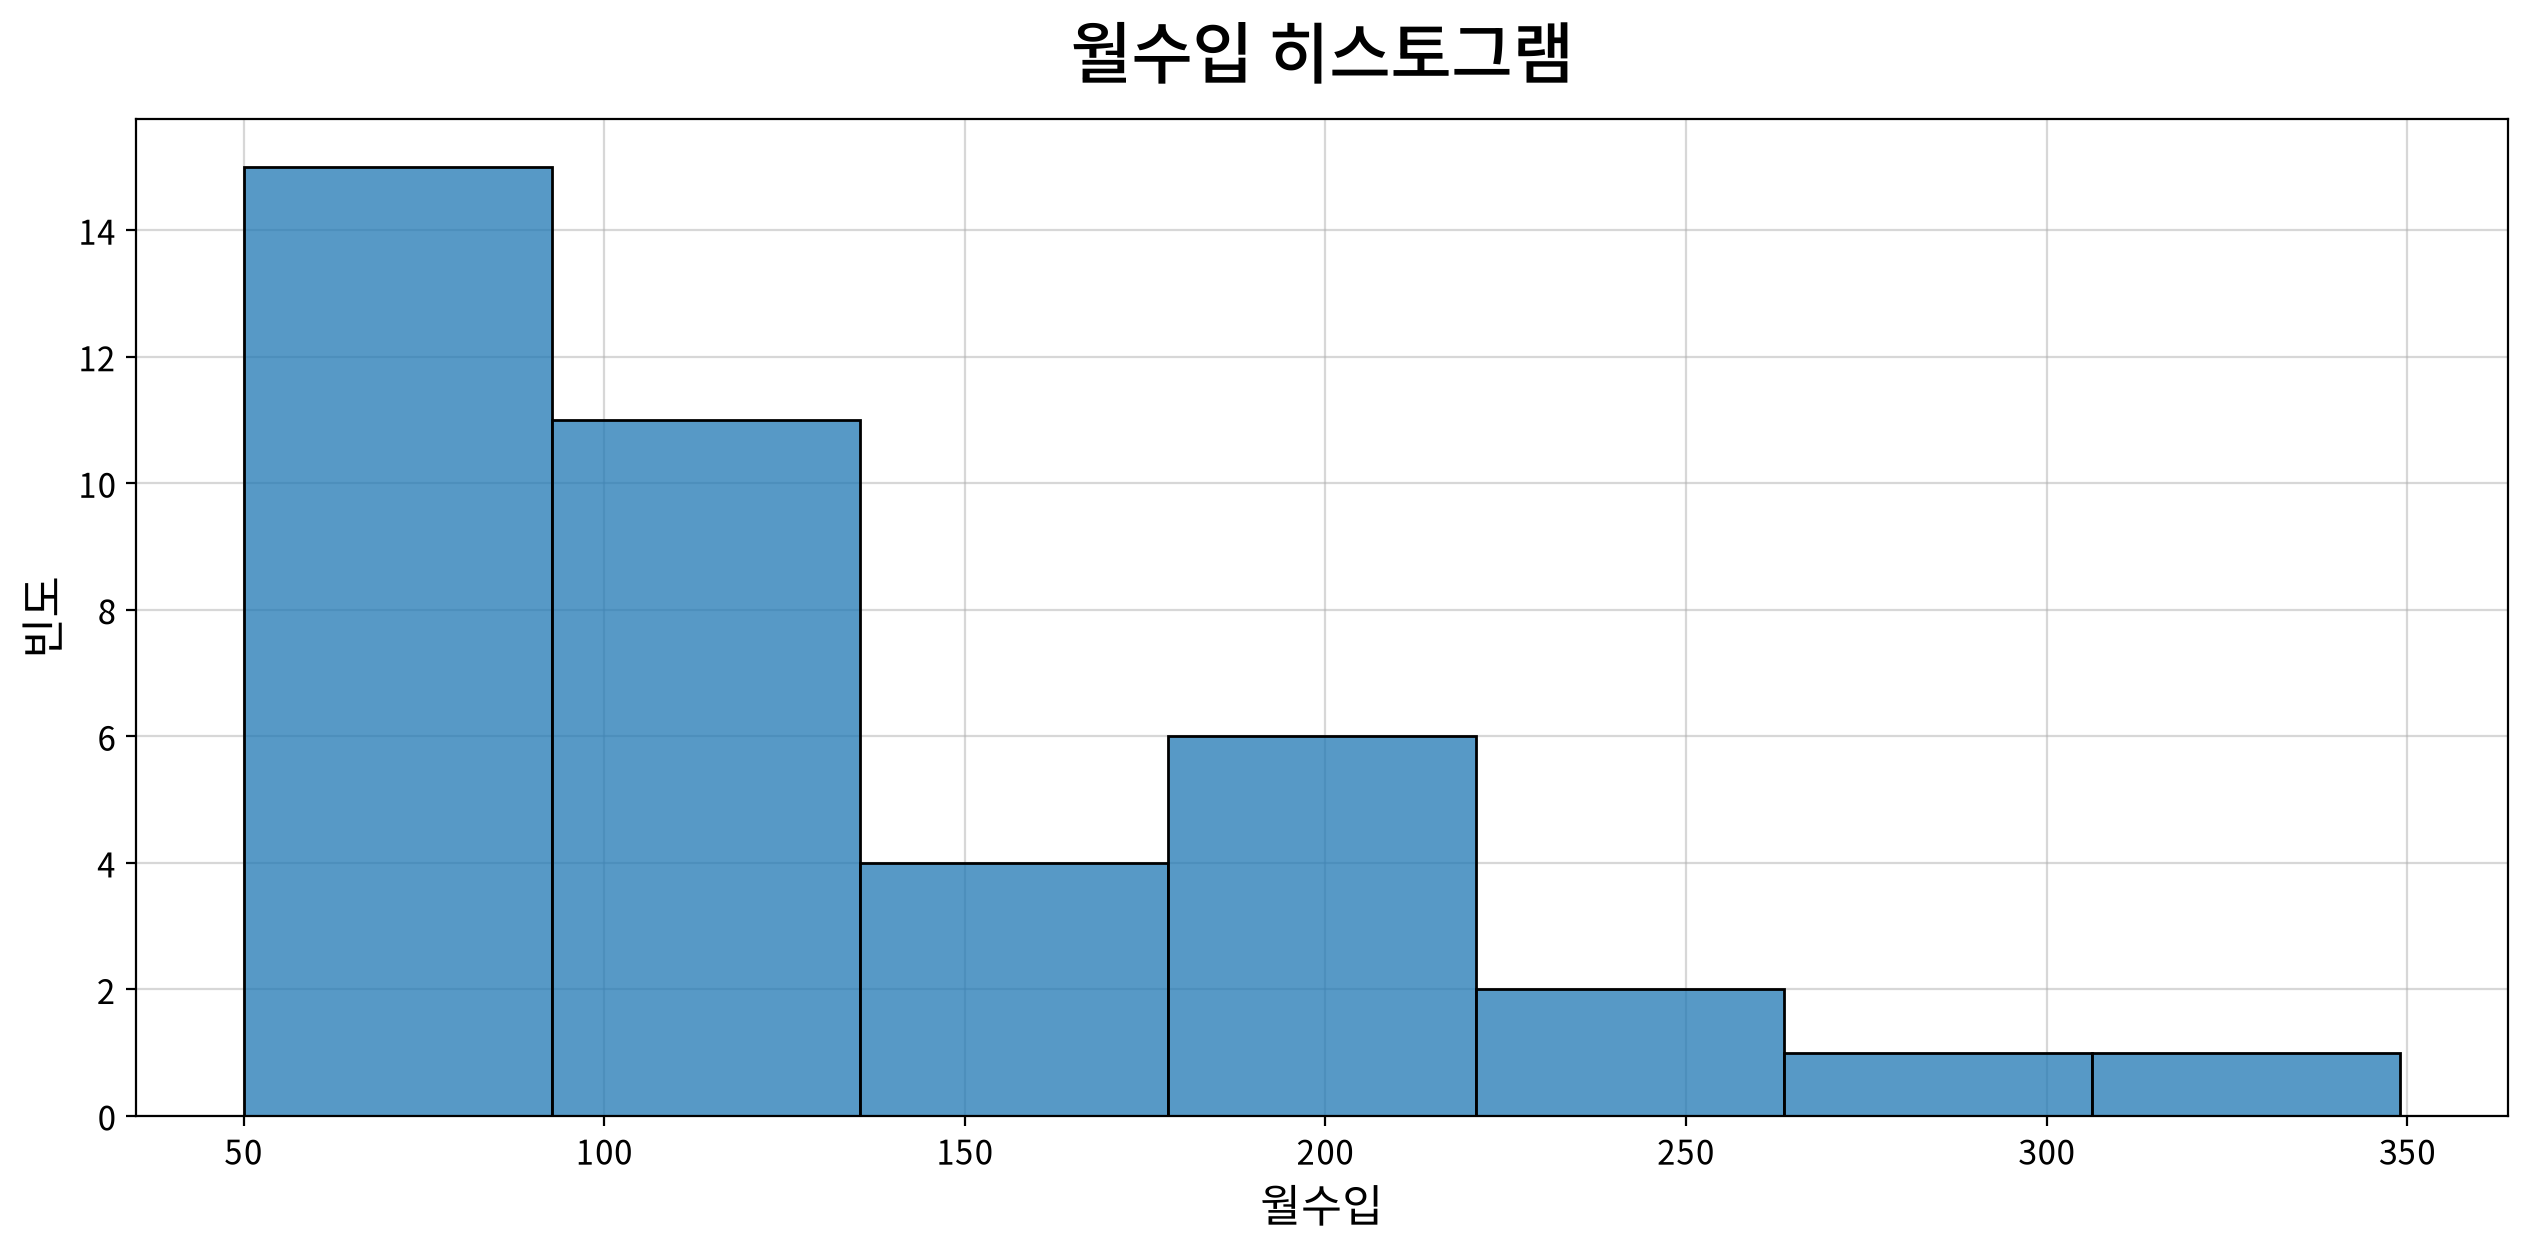

In [4]:
fig, ax = my_plot.init(title="월수입 히스토그램", xlabel="월수입", ylabel="빈도")

# 패턴1 - 자동인식 패턴
#sb.histplot(data=origin['월수입'])
# 패턴2 - 개별 데이터 직접 지정 패턴
#sb.histplot(x=origin['월수입'])
# 패턴3 - DataFrame + 컬럼명 패턴
sb.histplot(data=origin, x="월수입")

my_plot.show()

## #03. 히스토그램의 구간 설정

### 1. NumPy를 통해 정확한 구간경계 얻기

- `np.histogram()` 함수에 데이터와 구간수(bins)를 지정한다.
- `np.histogram()` 함수의 bins 파라미터에 리스트를 전달하면 히스토그램의 구간을 bins에 지정한 리스트로 설정할 수 있다.
  - 분석가의 주관에 따라 직접 정의한 리스트를 지정하는 것도 가능함
  - 예) [0, 100, 200, 300, 400, 500]

In [5]:
hist, bins = np.histogram(origin['월수입'], bins=5)
# 소수점 1째자리까지 남기고 반올림
bins = np.round(bins,1)
print("값:", hist)
print("구간:", bins)

값: [20  9  7  2  2]
구간: [ 50.  109.8 169.6 229.4 289.2 349. ]


### 2. NumPy를 통해 구한 구간경계를 히스토그램에 적용

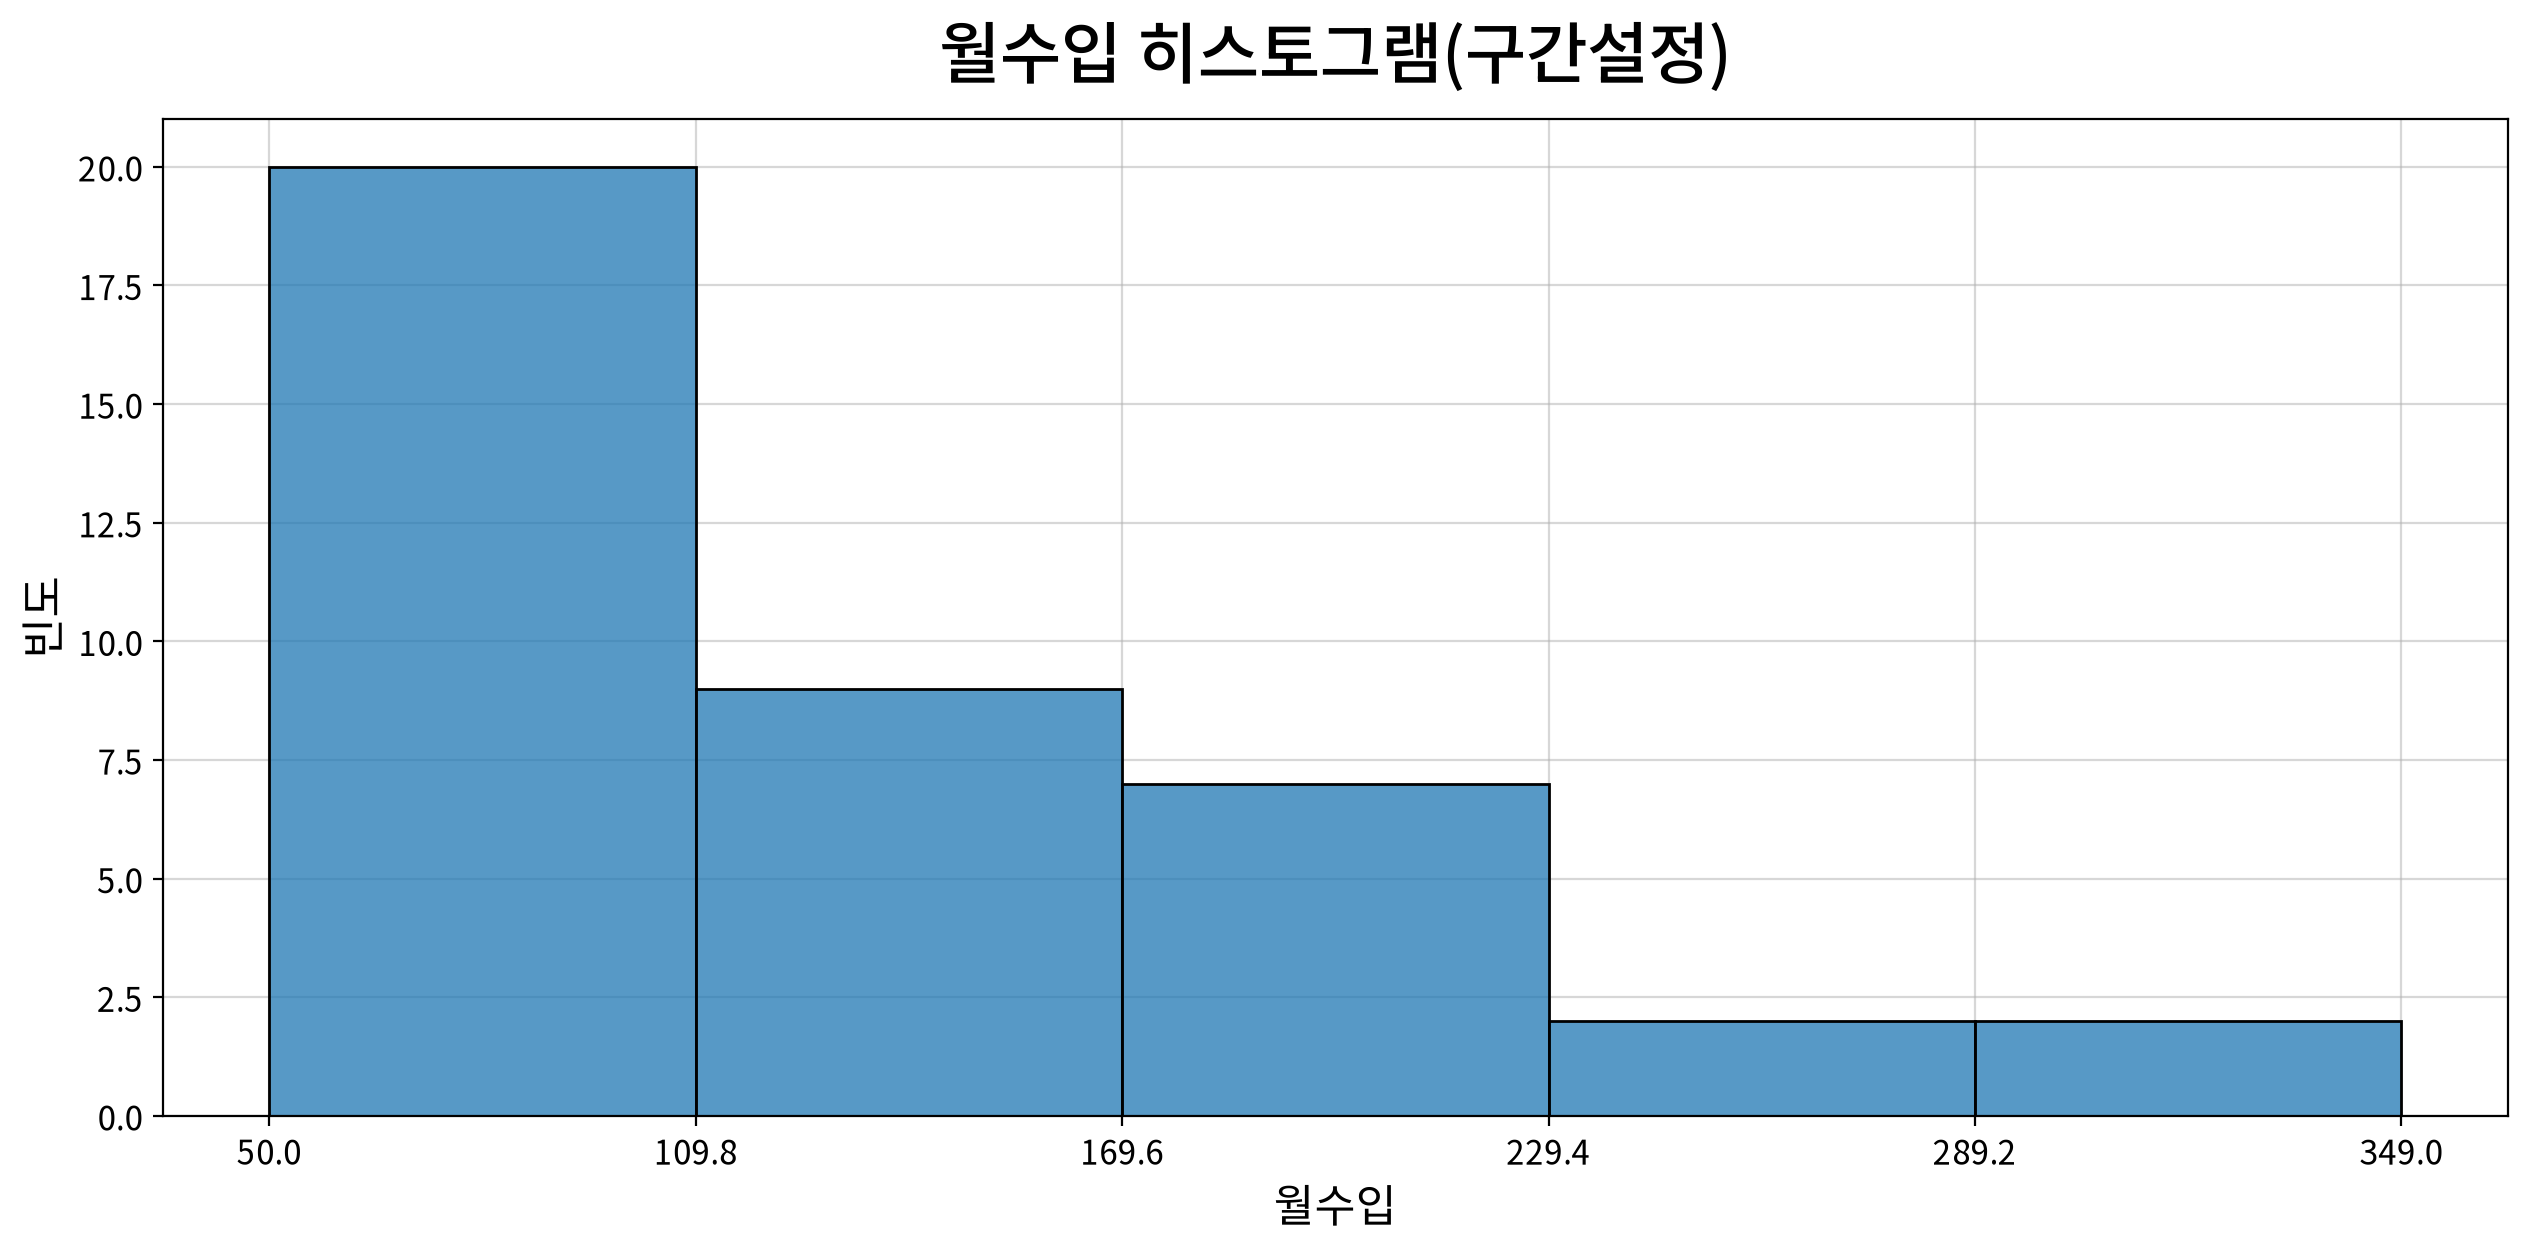

In [6]:
fig, ax = my_plot.init(title="월수입 히스토그램(구간설정)", xlabel="월수입", ylabel="빈도")

# 구간을 설정한 히스토그램
# -> bins는 이전 코드 블록에서 생성한 정보
sb.histplot(data=origin, x='월수입', bins=bins)

# x축 좌표에 구간값 표시하기
ax.set_xticks(bins, bins)

my_plot.show()

## #04. 히스토그램의 옵션 설정

### 1. 커널밀도와 함께 표시하기

- `kde=True` 파라미터를 추가한다.

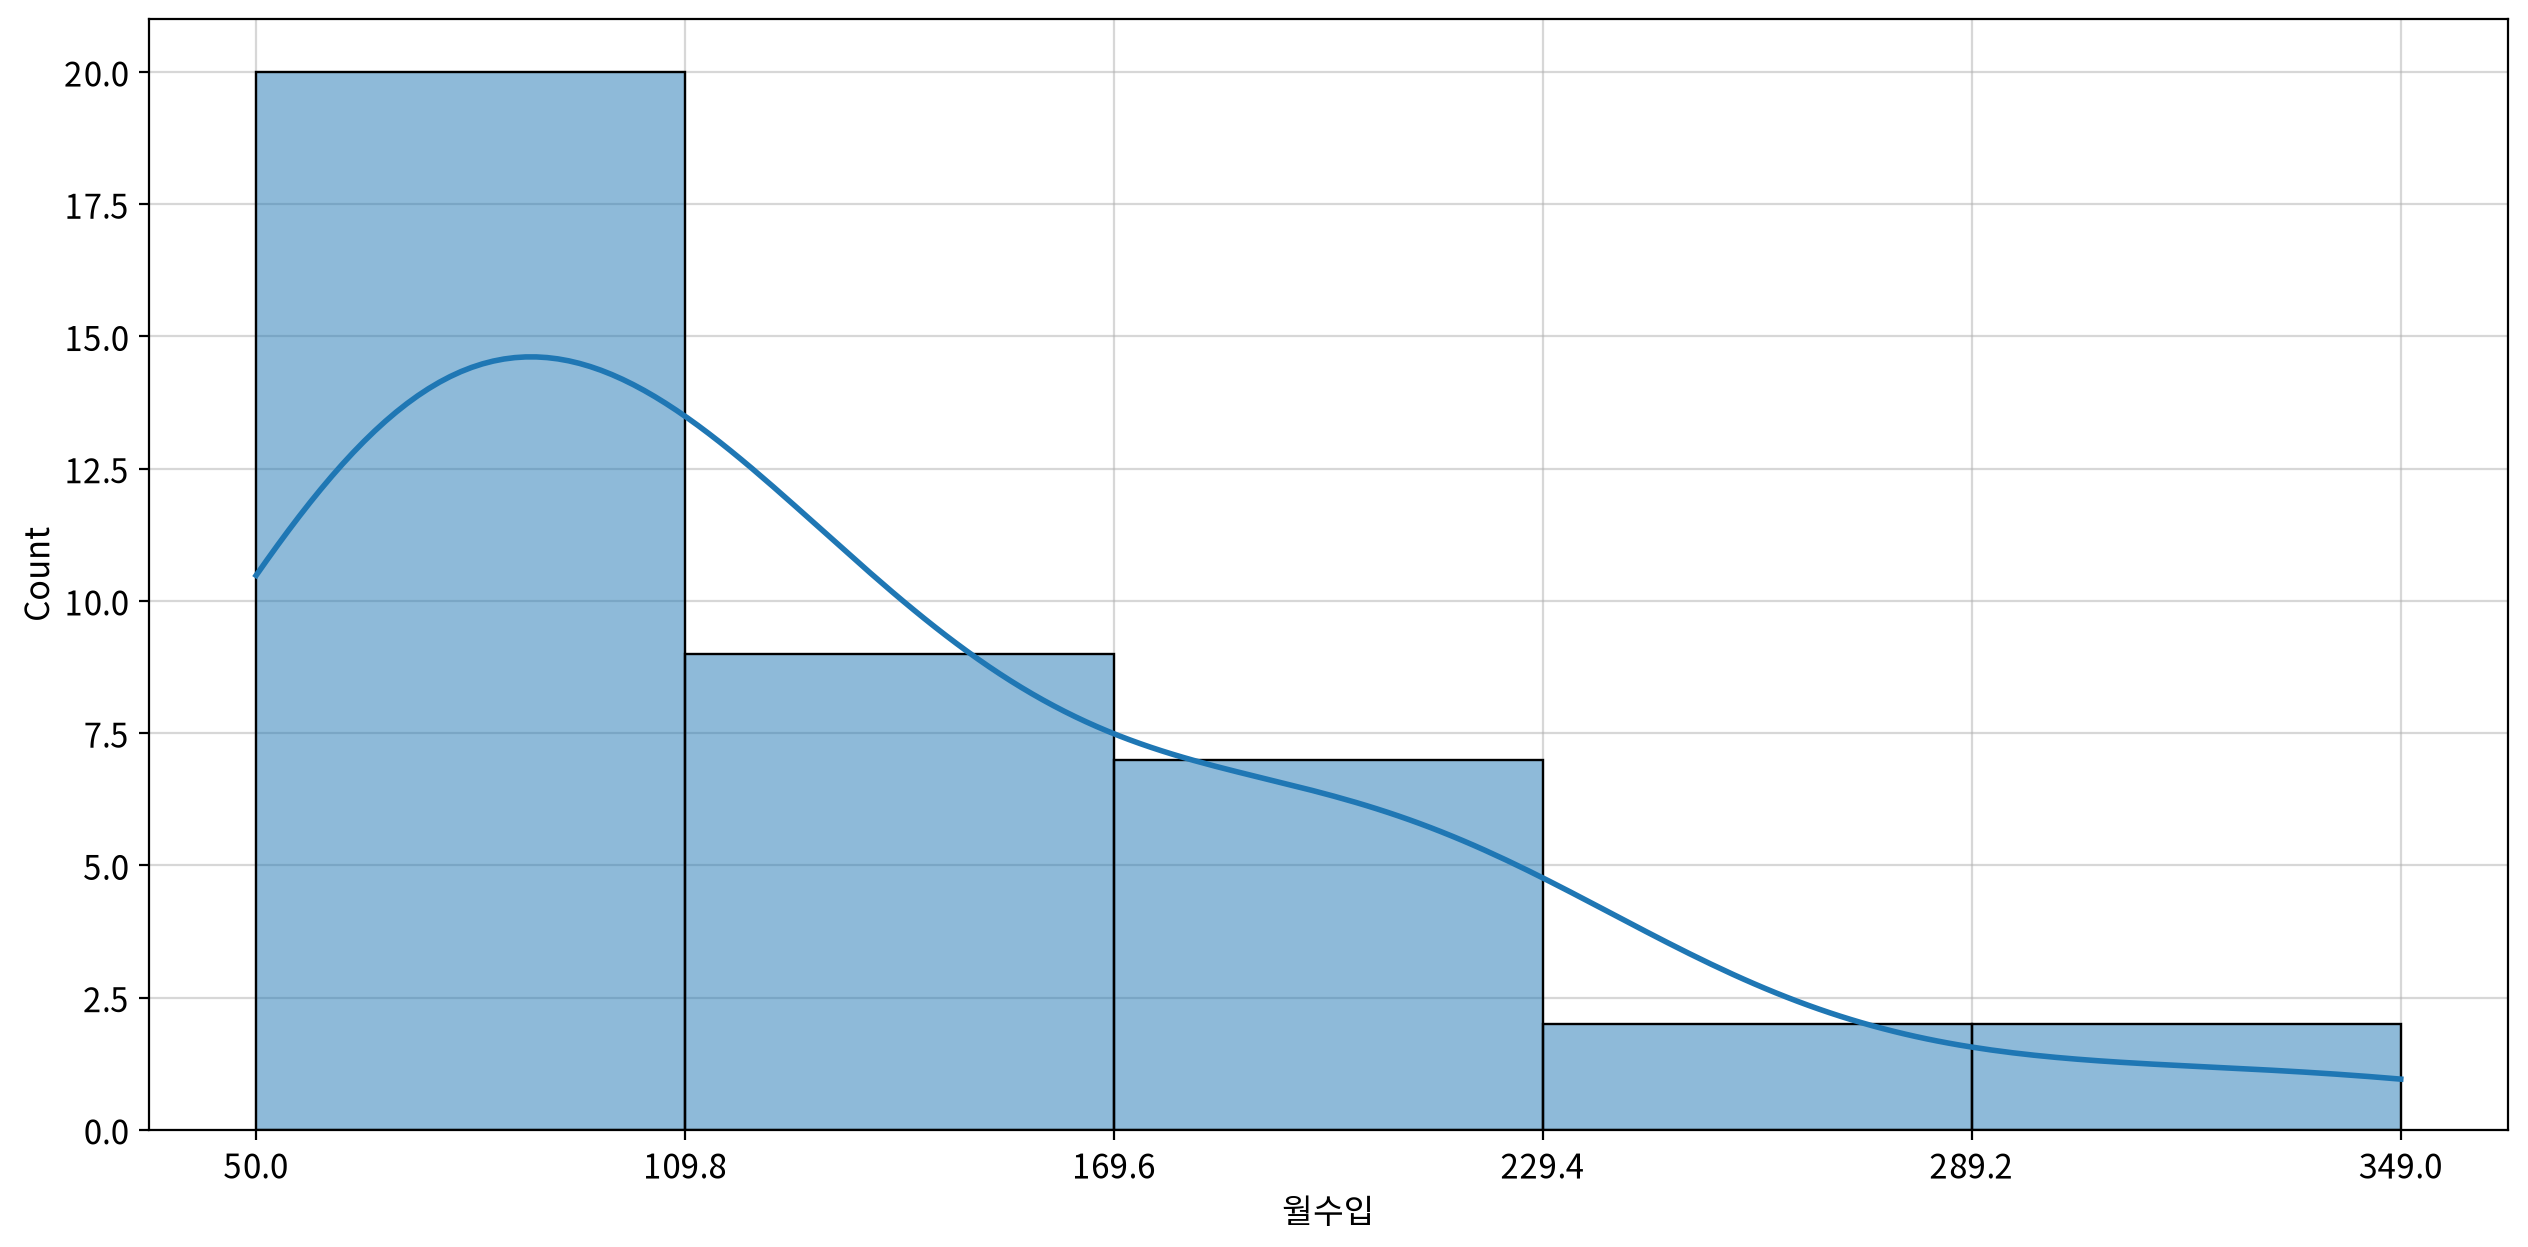

In [7]:
# 그래프 초기화
fig, ax = my_plot.init()

# 구간을 설정한 히스토그램 -> bins는 이전 코드 블록에서 생성한 정보
sb.histplot(data=origin, x='월수입', bins=bins, kde=True, linewidth=0.85)

# x축 좌표에 구간값 표시하기
ax.set_xticks(bins,bins)

# 출력
my_plot.show()

### 2. 범주 구분, 선 색상/굵기 설정하기

- 성별에 따른 월 수입 히스토그램

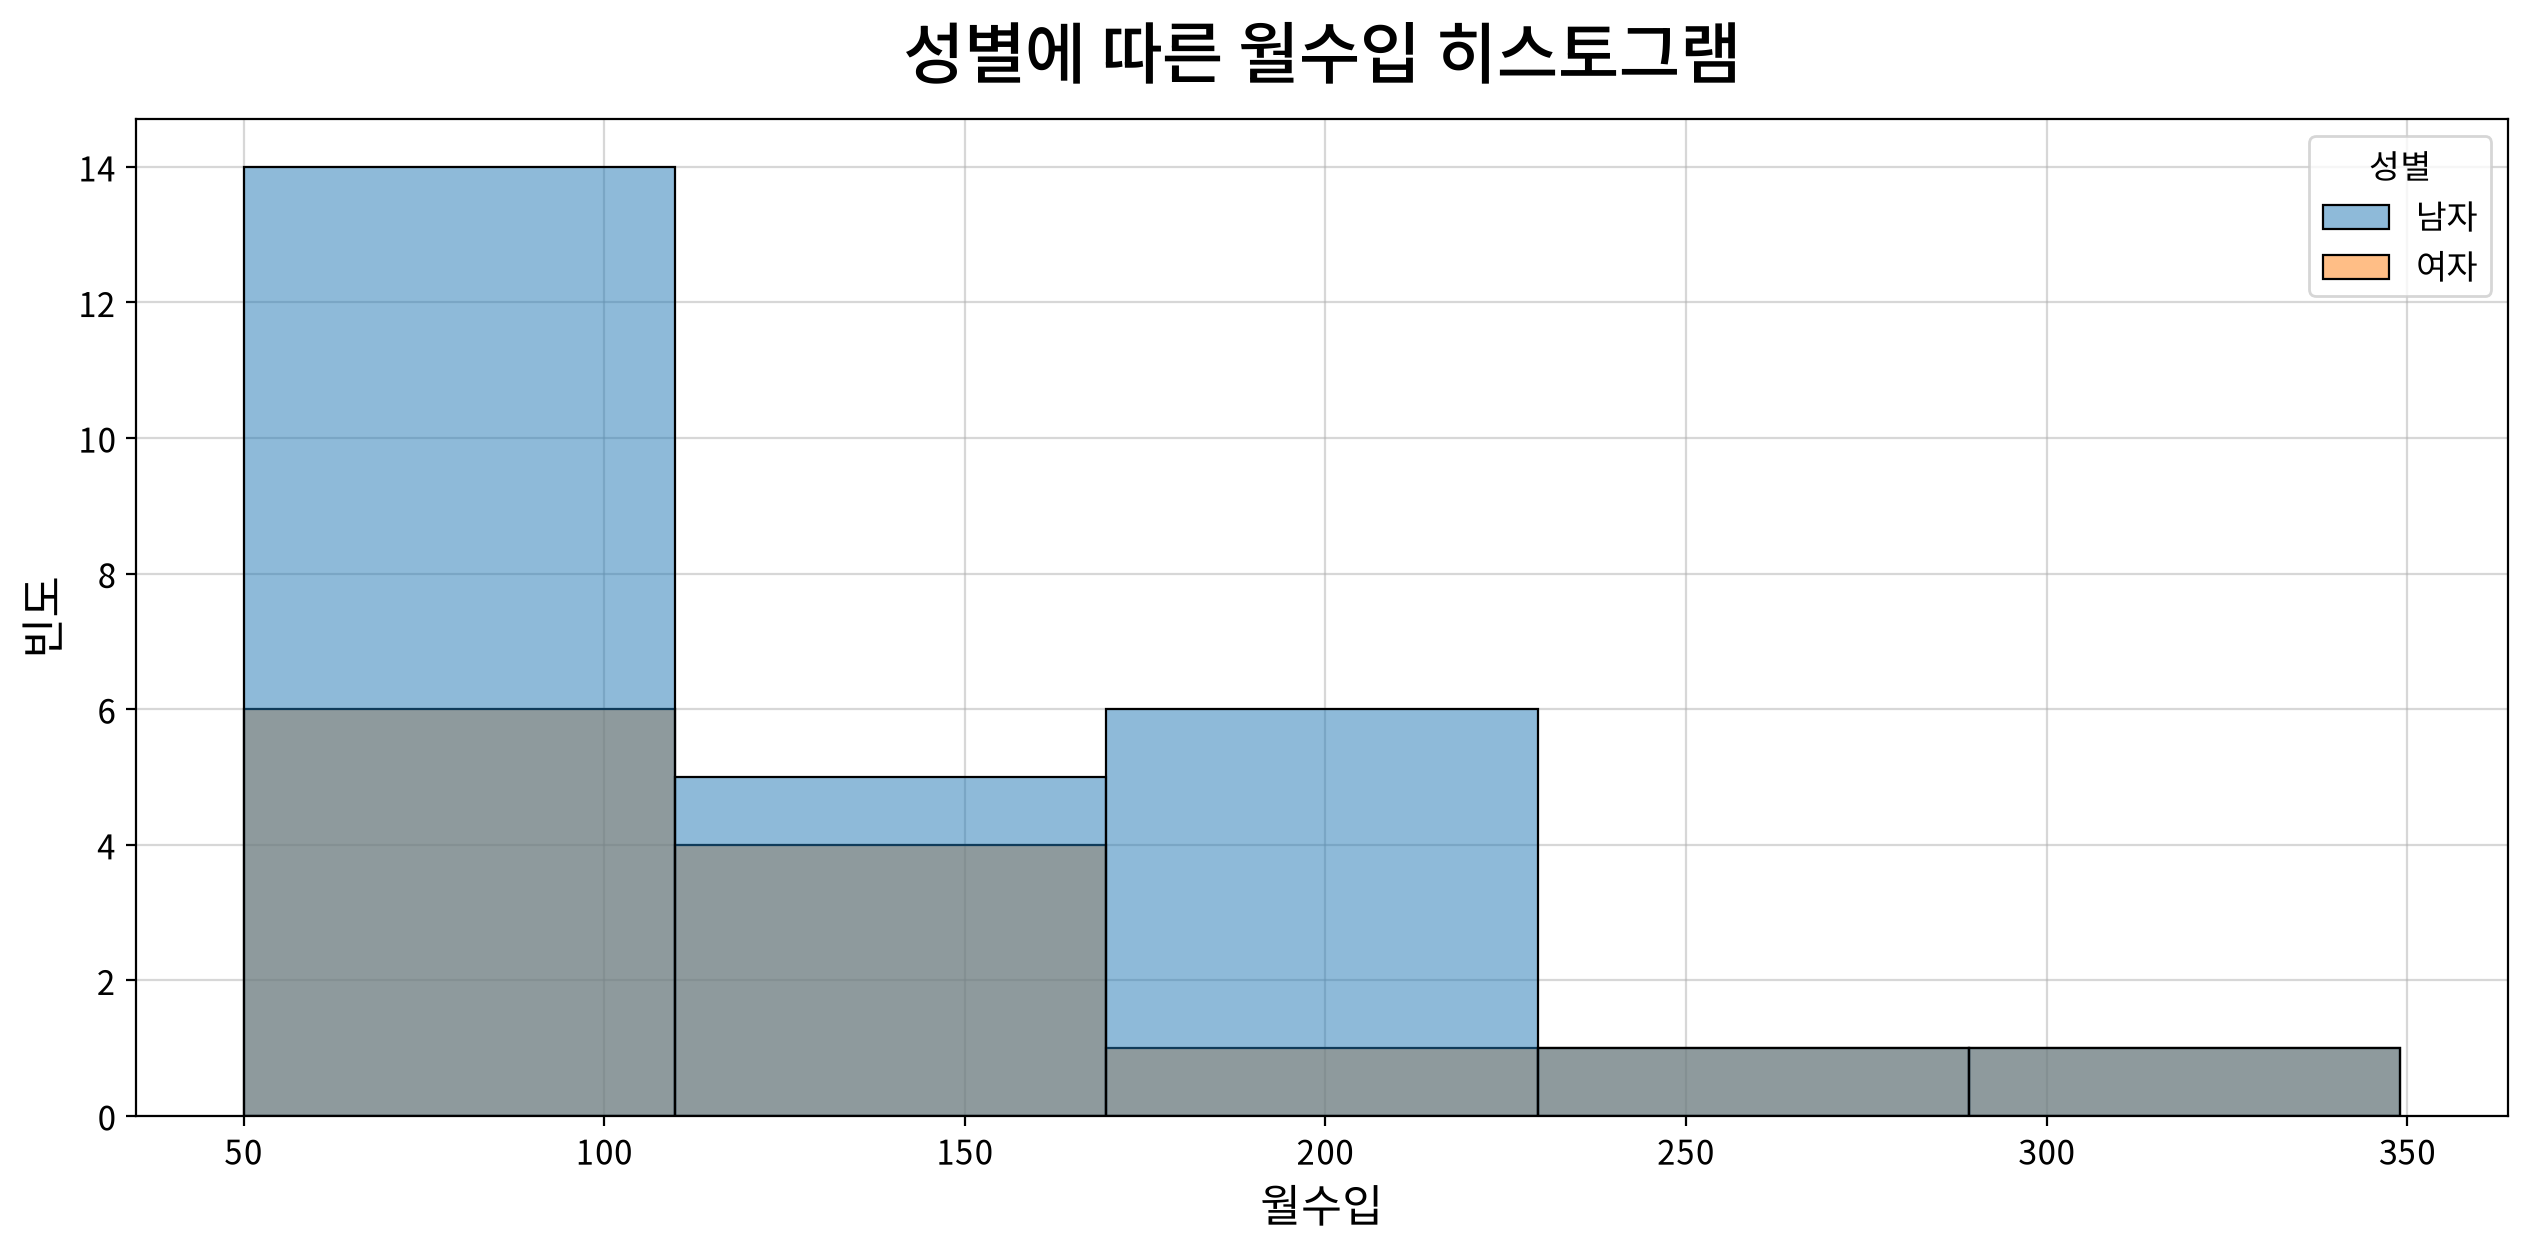

In [8]:
fig, ax = my_plot.init(title="성별에 따른 월수입 히스토그램", xlabel="월수입", ylabel="빈도")

sb.histplot(data=origin, x='월수입', hue="성별", bins=bins, edgecolor="#000000", linewidth=0.8)

my_plot.show()

## #05. 모듈화 기능 확인

### 1. 히스토그램 모듈 사용하기

- 모듈 코드의 변경사항을 jupyter에 인식시키기 위해 jupyter를 재시작 후 기존 코드를 모두 재실행 해야 한다.

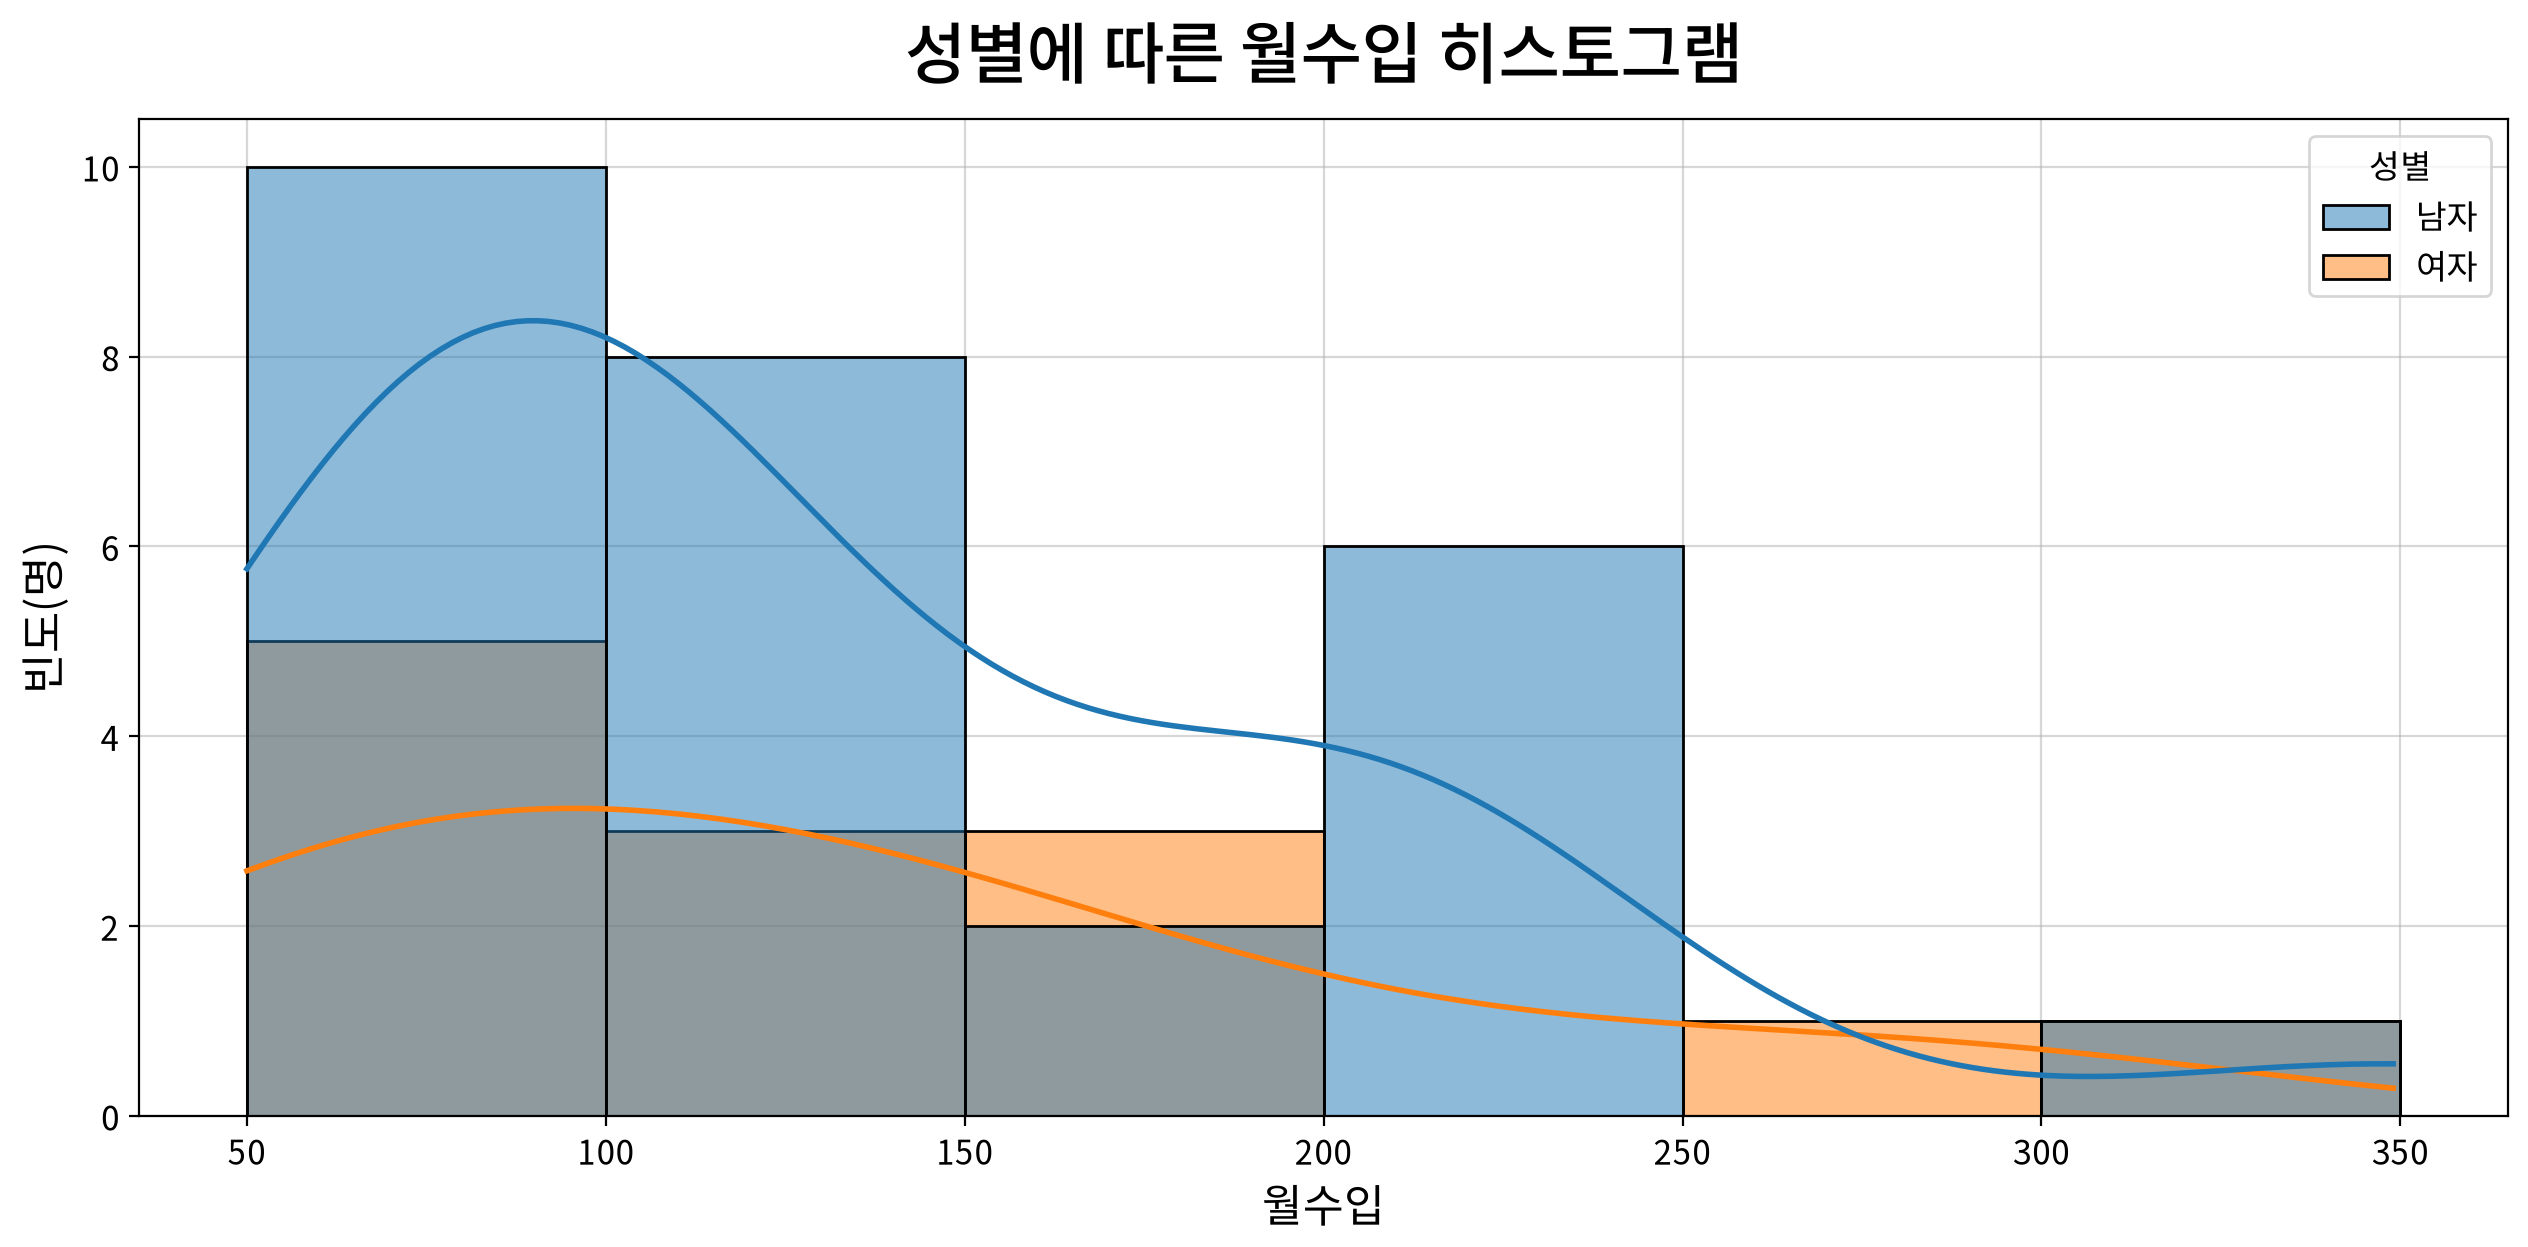

In [9]:
my_plot.histplot(data=origin, x='월수입', hue='성별', 
                 bins=[50, 100, 150, 200, 250, 300, 350], kde=True,
                 title='성별에 따른 월수입 히스토그램', 
                 xlabel='월수입', ylabel='빈도(명)')

### 연습문제. 두 학과의 성적 분포 비교
#### stat_comp_grade 데이터셋은 통계학(STAT) 전공 학생과 전산학(COMP) 학생의 통계학 과목에 대한 중간고사 성적과 기말고사 성적을 나타낸표
##### o 전공별로 중간고사와 기말고사 성적에 대한 히스토그램을 각각 시각화 하고, 다음의 물음에 답하시오.
##### o 히스토그램의 구간 수는 6개로 하고, 구간은 자동으로 도출되는 형태로 시각화하세요.
##### o 커널 밀도를 표시하는 것은 선택사항입니다. (문제풀이에 영향없음.)
##### o 총 4개의 그래프가 도출되어야 합니다.
#####   -> 통계학 전공 학생의 중간고사/기말고사, 전산학 학생의 중간고사/기말고사

In [10]:
# 0. 필요 모듈 활성화
from jussam import load_data
from helper import *
import seaborn as sb
import numpy as np

# 1. 데이터 불러오기
stat = load_data("stat_comp_grade")
stat.info()
stat

📚 통계학 전공(STAT) 학생과 전산학 전공(COMP) 학생의 통계학 과목에 대한 중간고사 성적과 기말시험 성적 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   전공      20 non-null     str  
 1   중간고사    20 non-null     int64
 2   기말고사    20 non-null     int64
dtypes: int64(2), str(1)
memory usage: 692.0 bytes


,전공,중간고사,기말고사
0,STAT,34,86
1,STAT,50,77
2,STAT,75,74
3,COMP,76,96
4,COMP,61,78
5,COMP,65,40
6,COMP,31,68
7,STAT,47,57
8,STAT,94,82
9,COMP,49,57


In [17]:
# 2. 히스토그램 시각화 전 데이터 쪼개기
stat_stat = stat[stat['전공']=='STAT']
stat_stat
stat_comp = stat[stat['전공']=='COMP']
stat_comp

,전공,중간고사,기말고사
3,COMP,76,96
4,COMP,61,78
5,COMP,65,40
6,COMP,31,68
9,COMP,49,57
14,COMP,80,85
15,COMP,87,90
19,COMP,76,85


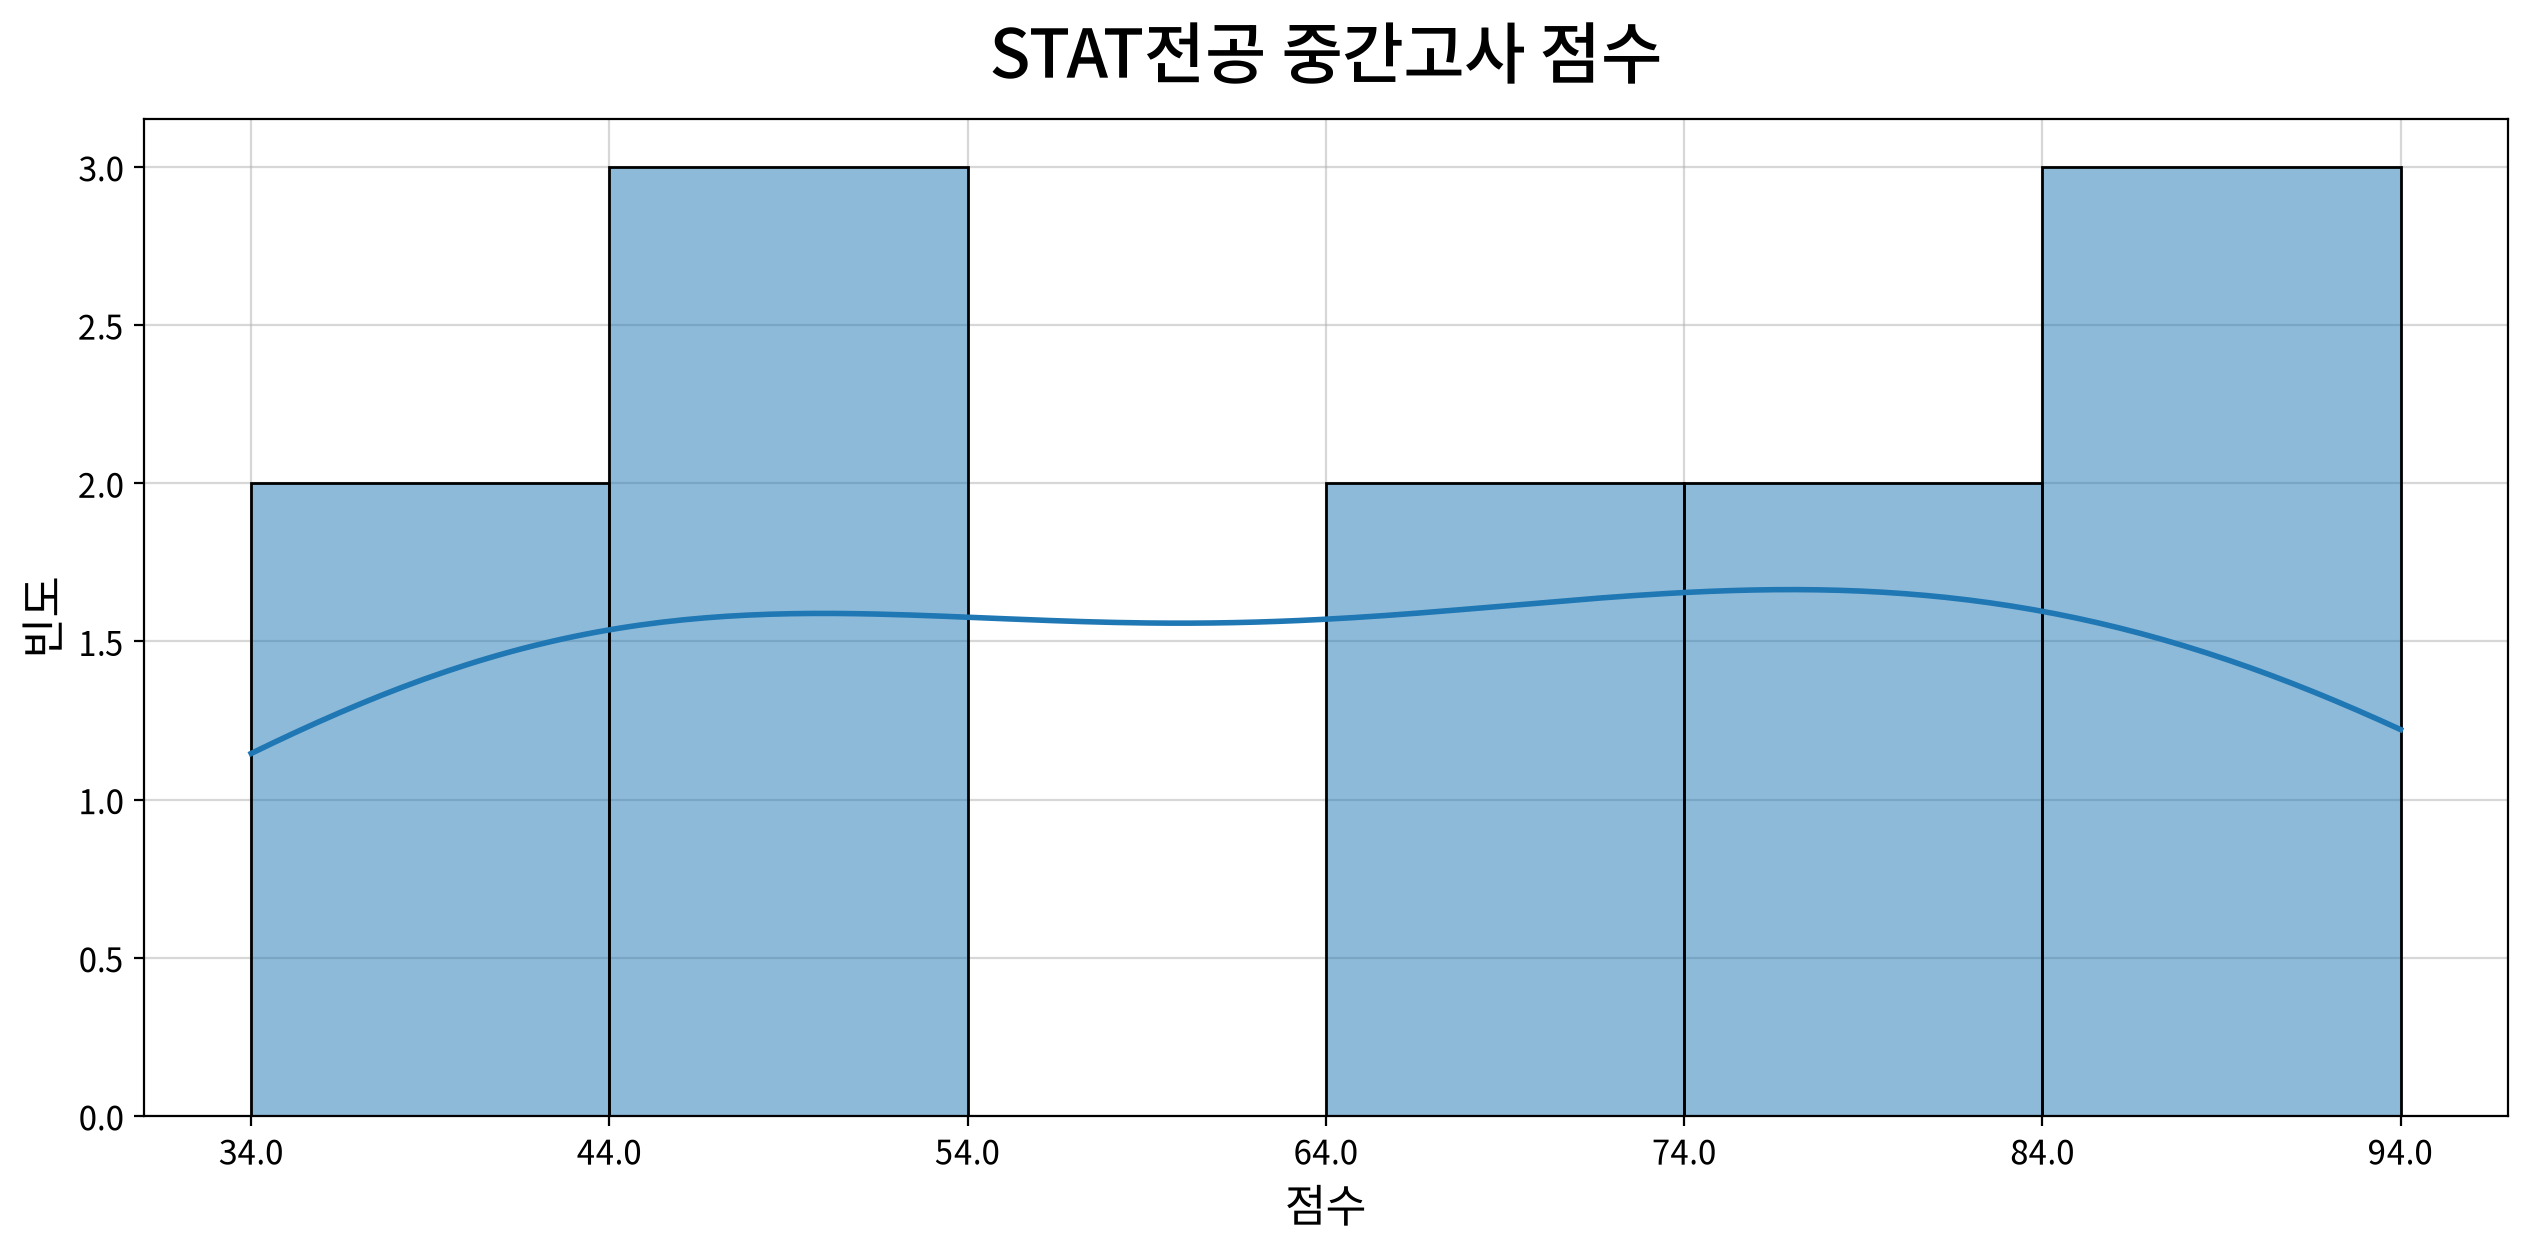

<Figure size 1280x960 with 0 Axes>

In [24]:
# 3. STAT전공 중간고사 점수
my_plot.histplot(data=stat_stat, title="STAT전공 중간고사 점수", x="중간고사", xlabel="점수", ylabel="빈도", kde=True, bins=6)
my_plot.show()

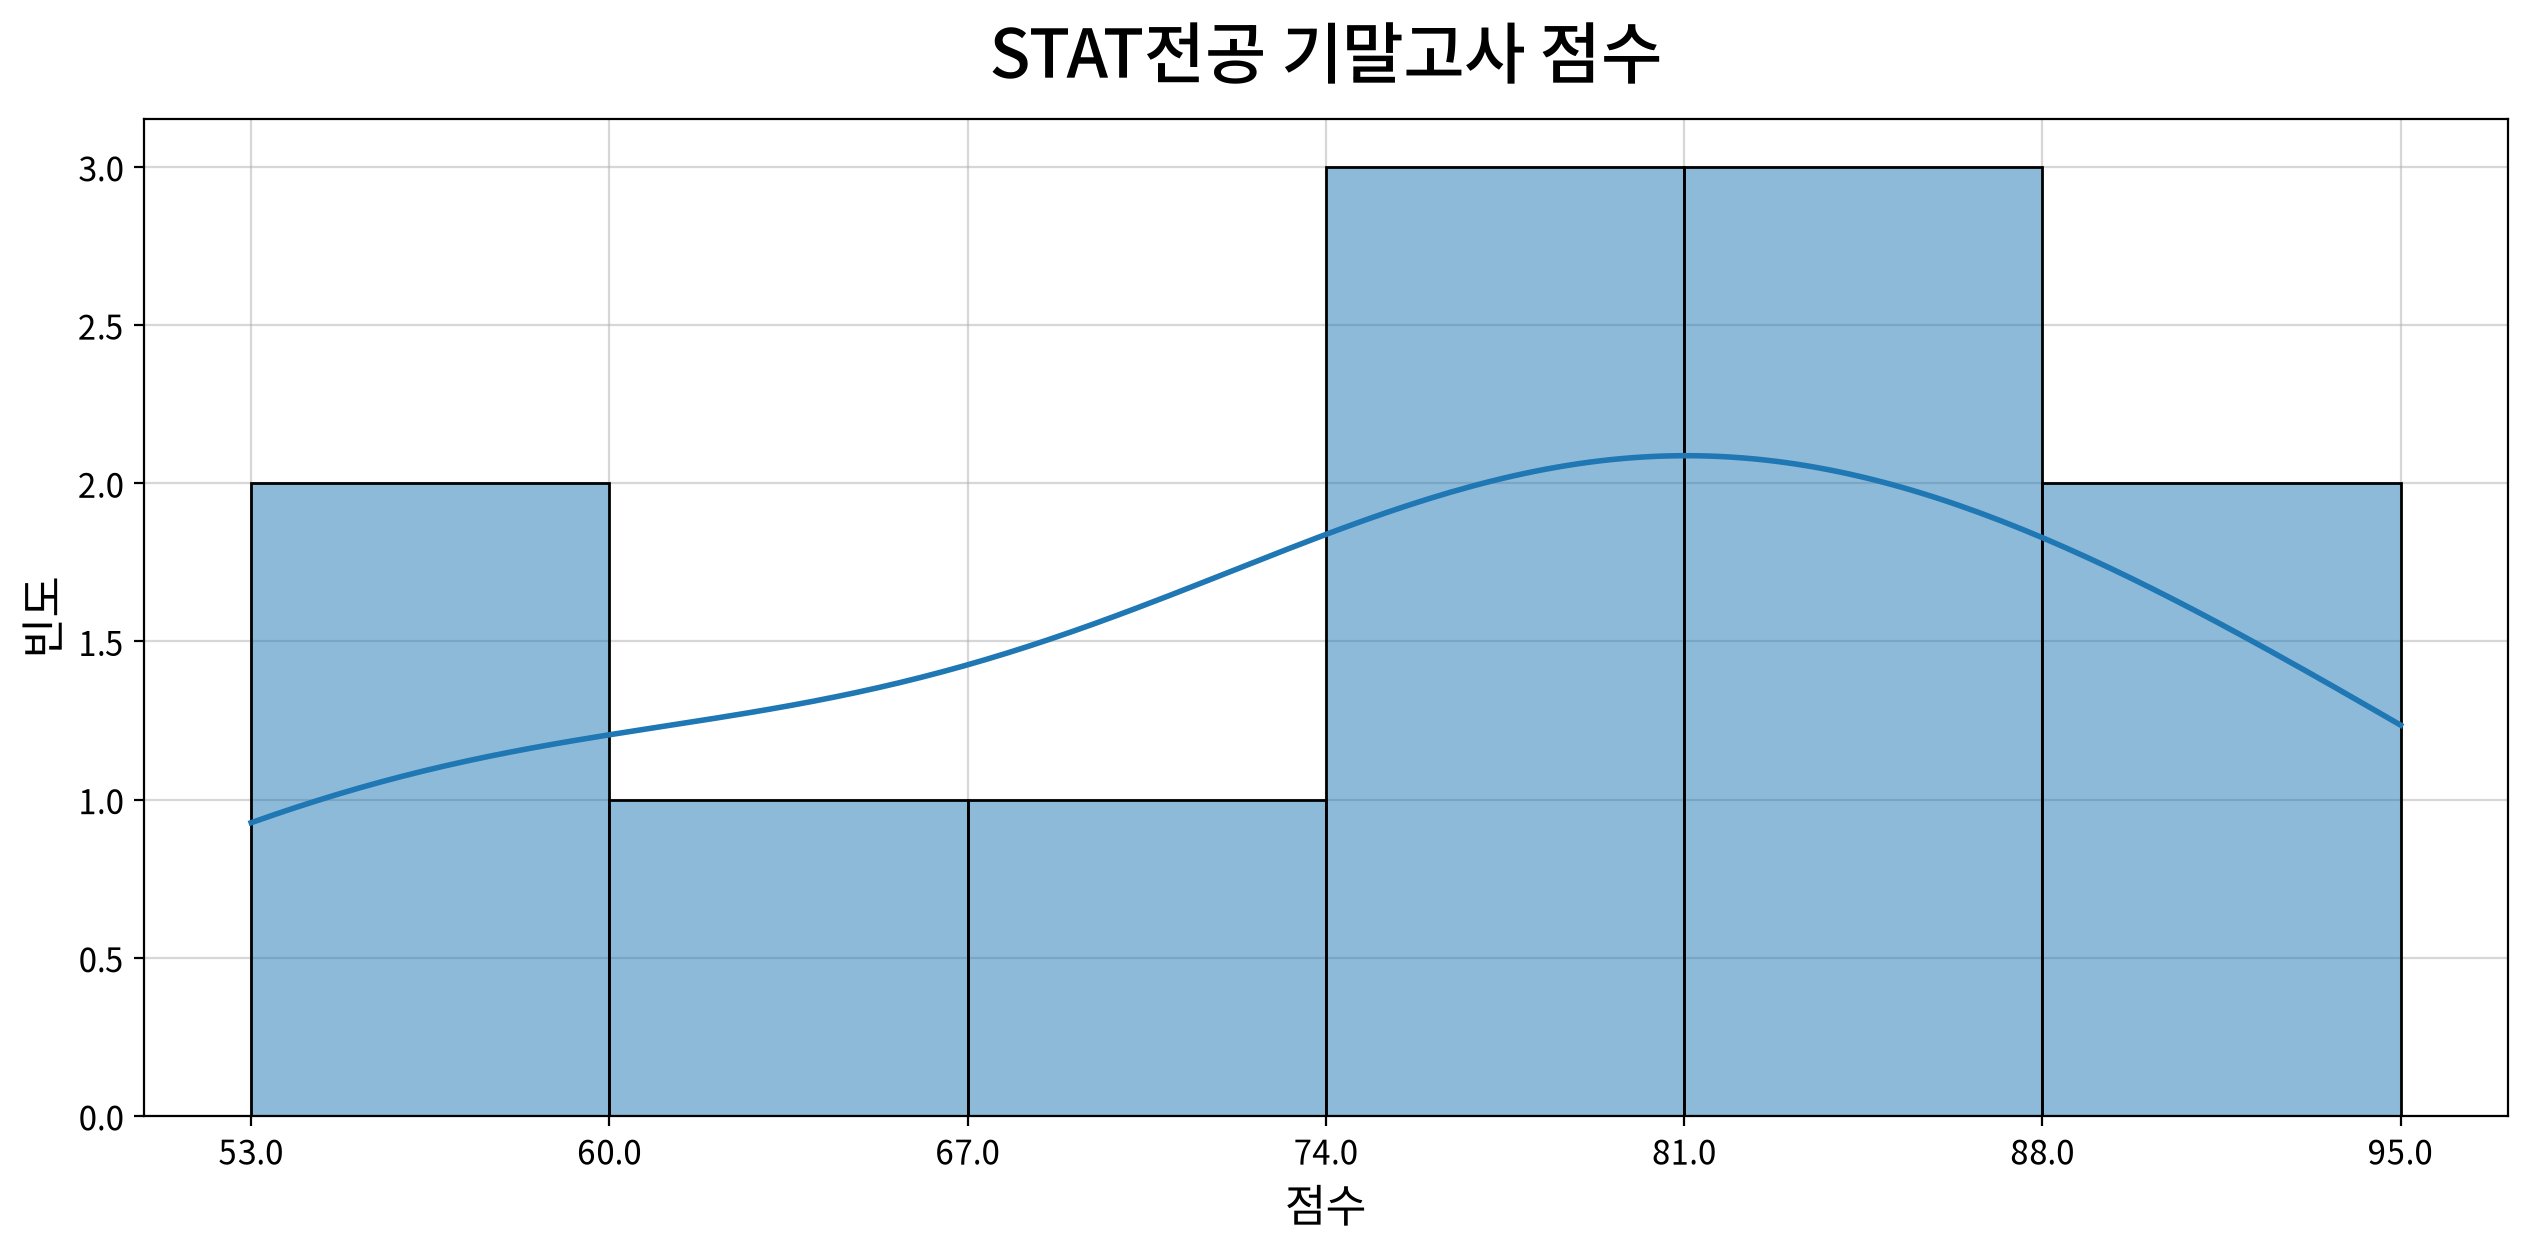

<Figure size 1280x960 with 0 Axes>

In [25]:
# 3. STAT전공 기말고사 점수
my_plot.histplot(data=stat_stat, title="STAT전공 기말고사 점수",x="기말고사", xlabel="점수", ylabel="빈도", kde=True, bins=6)
my_plot.show()

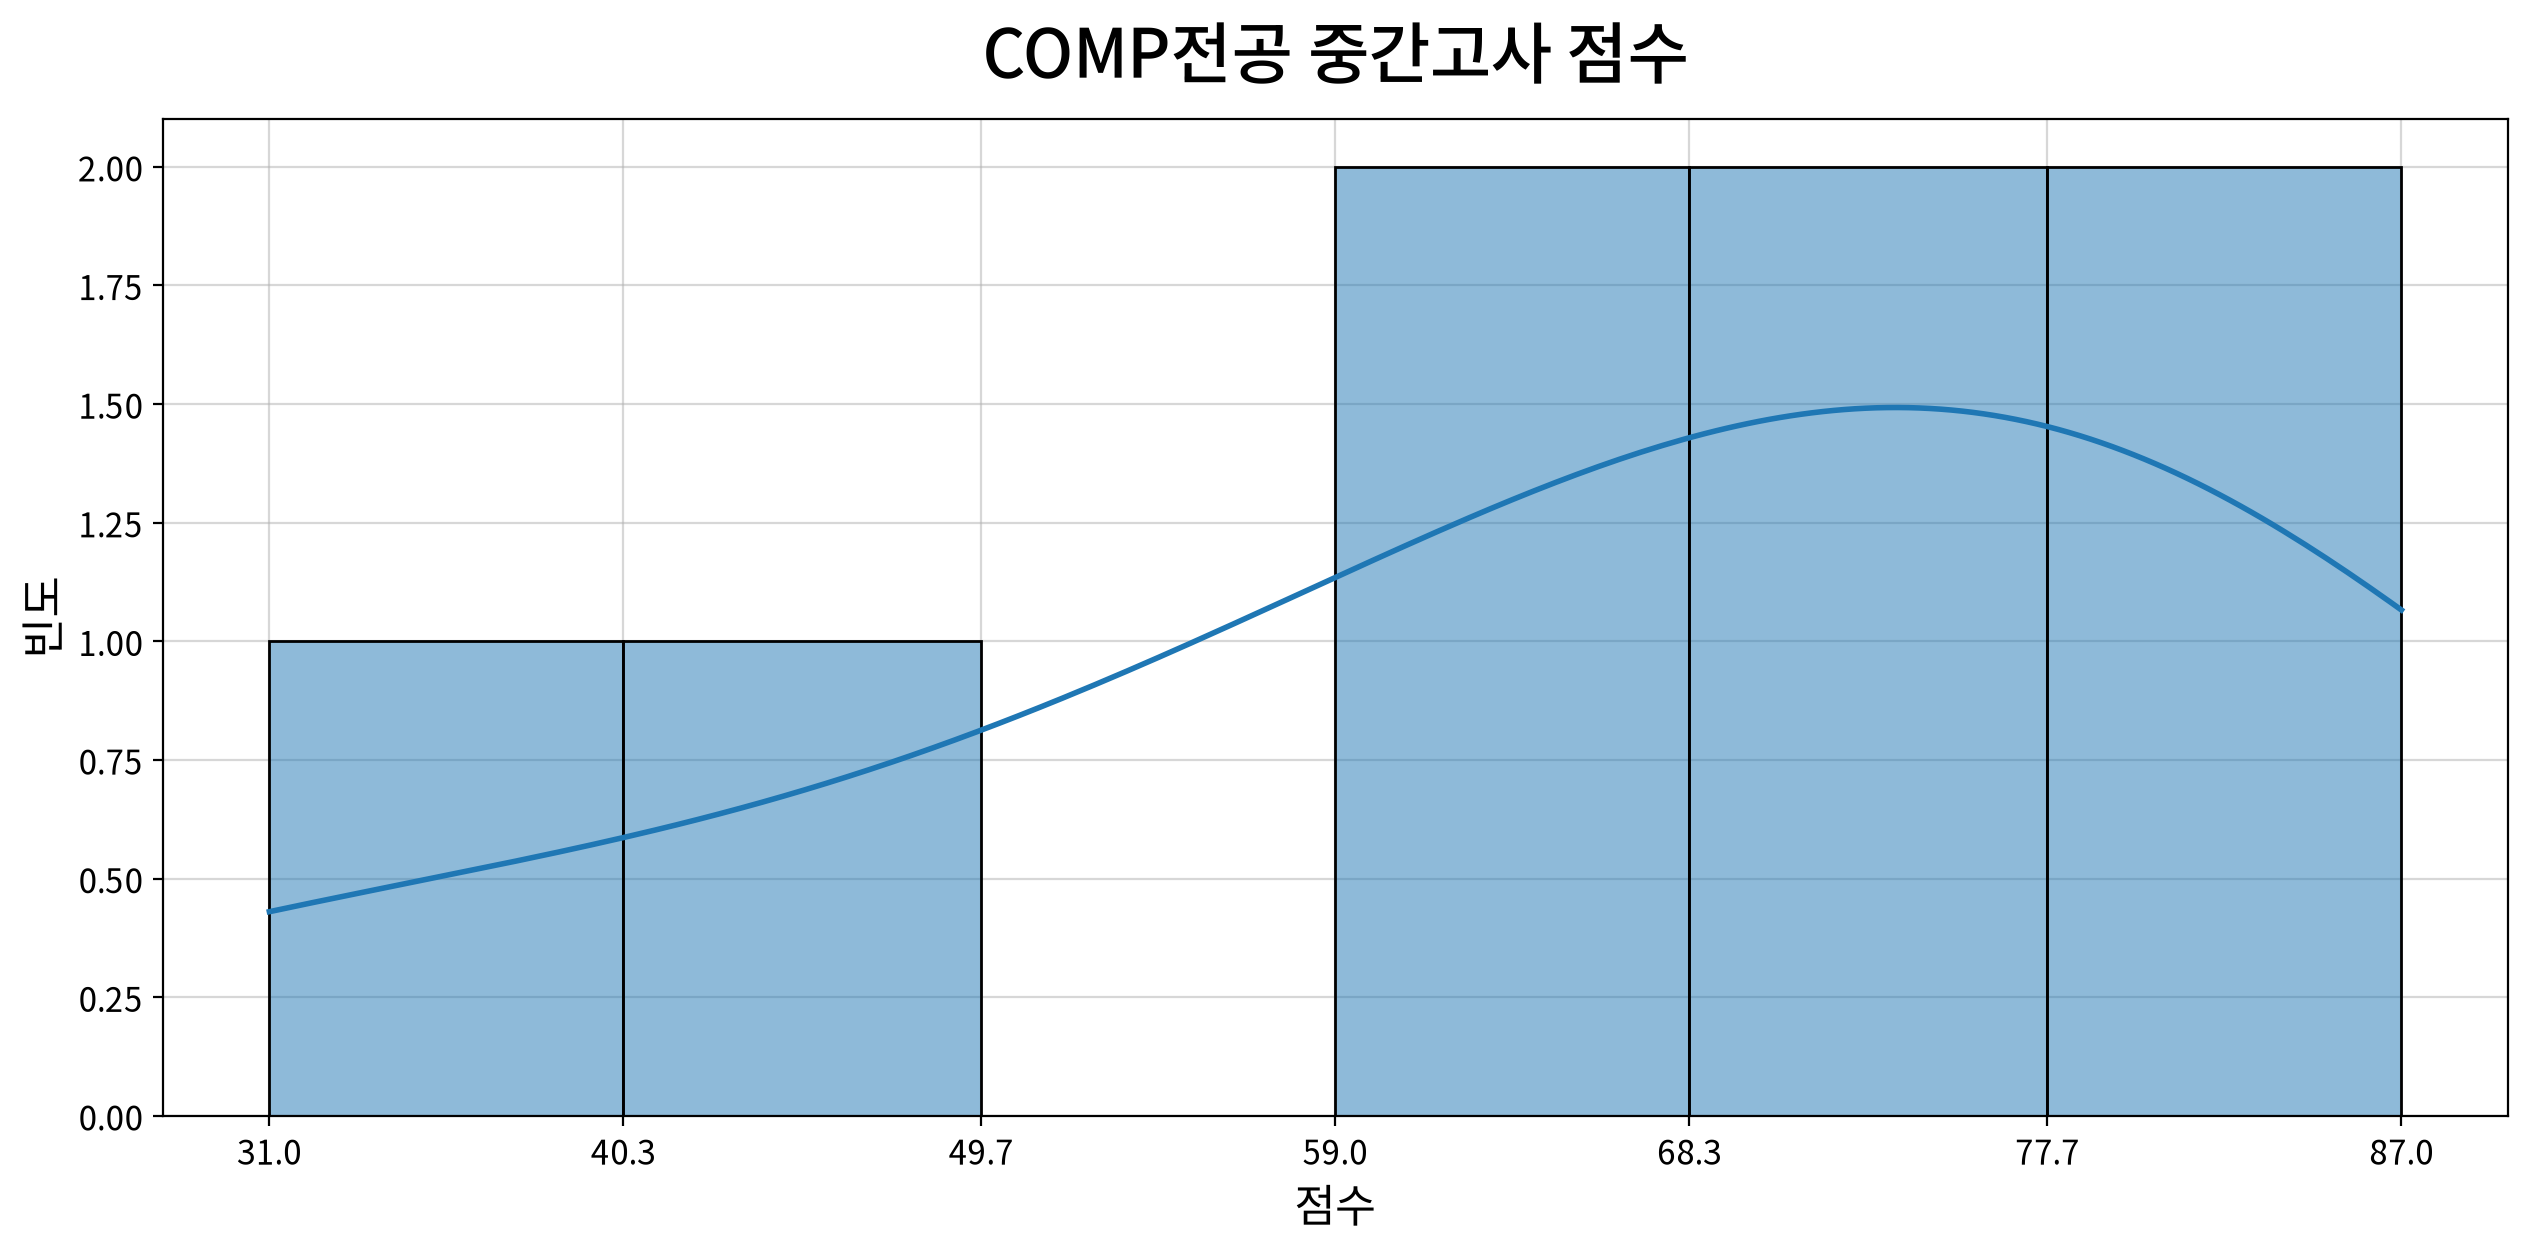

<Figure size 1280x960 with 0 Axes>

In [26]:
# 4. COMP전공 중간고사 점수
my_plot.histplot(data=stat_comp, title="COMP전공 중간고사 점수",x="중간고사", xlabel="점수", ylabel="빈도", kde=True, bins=6)
my_plot.show()

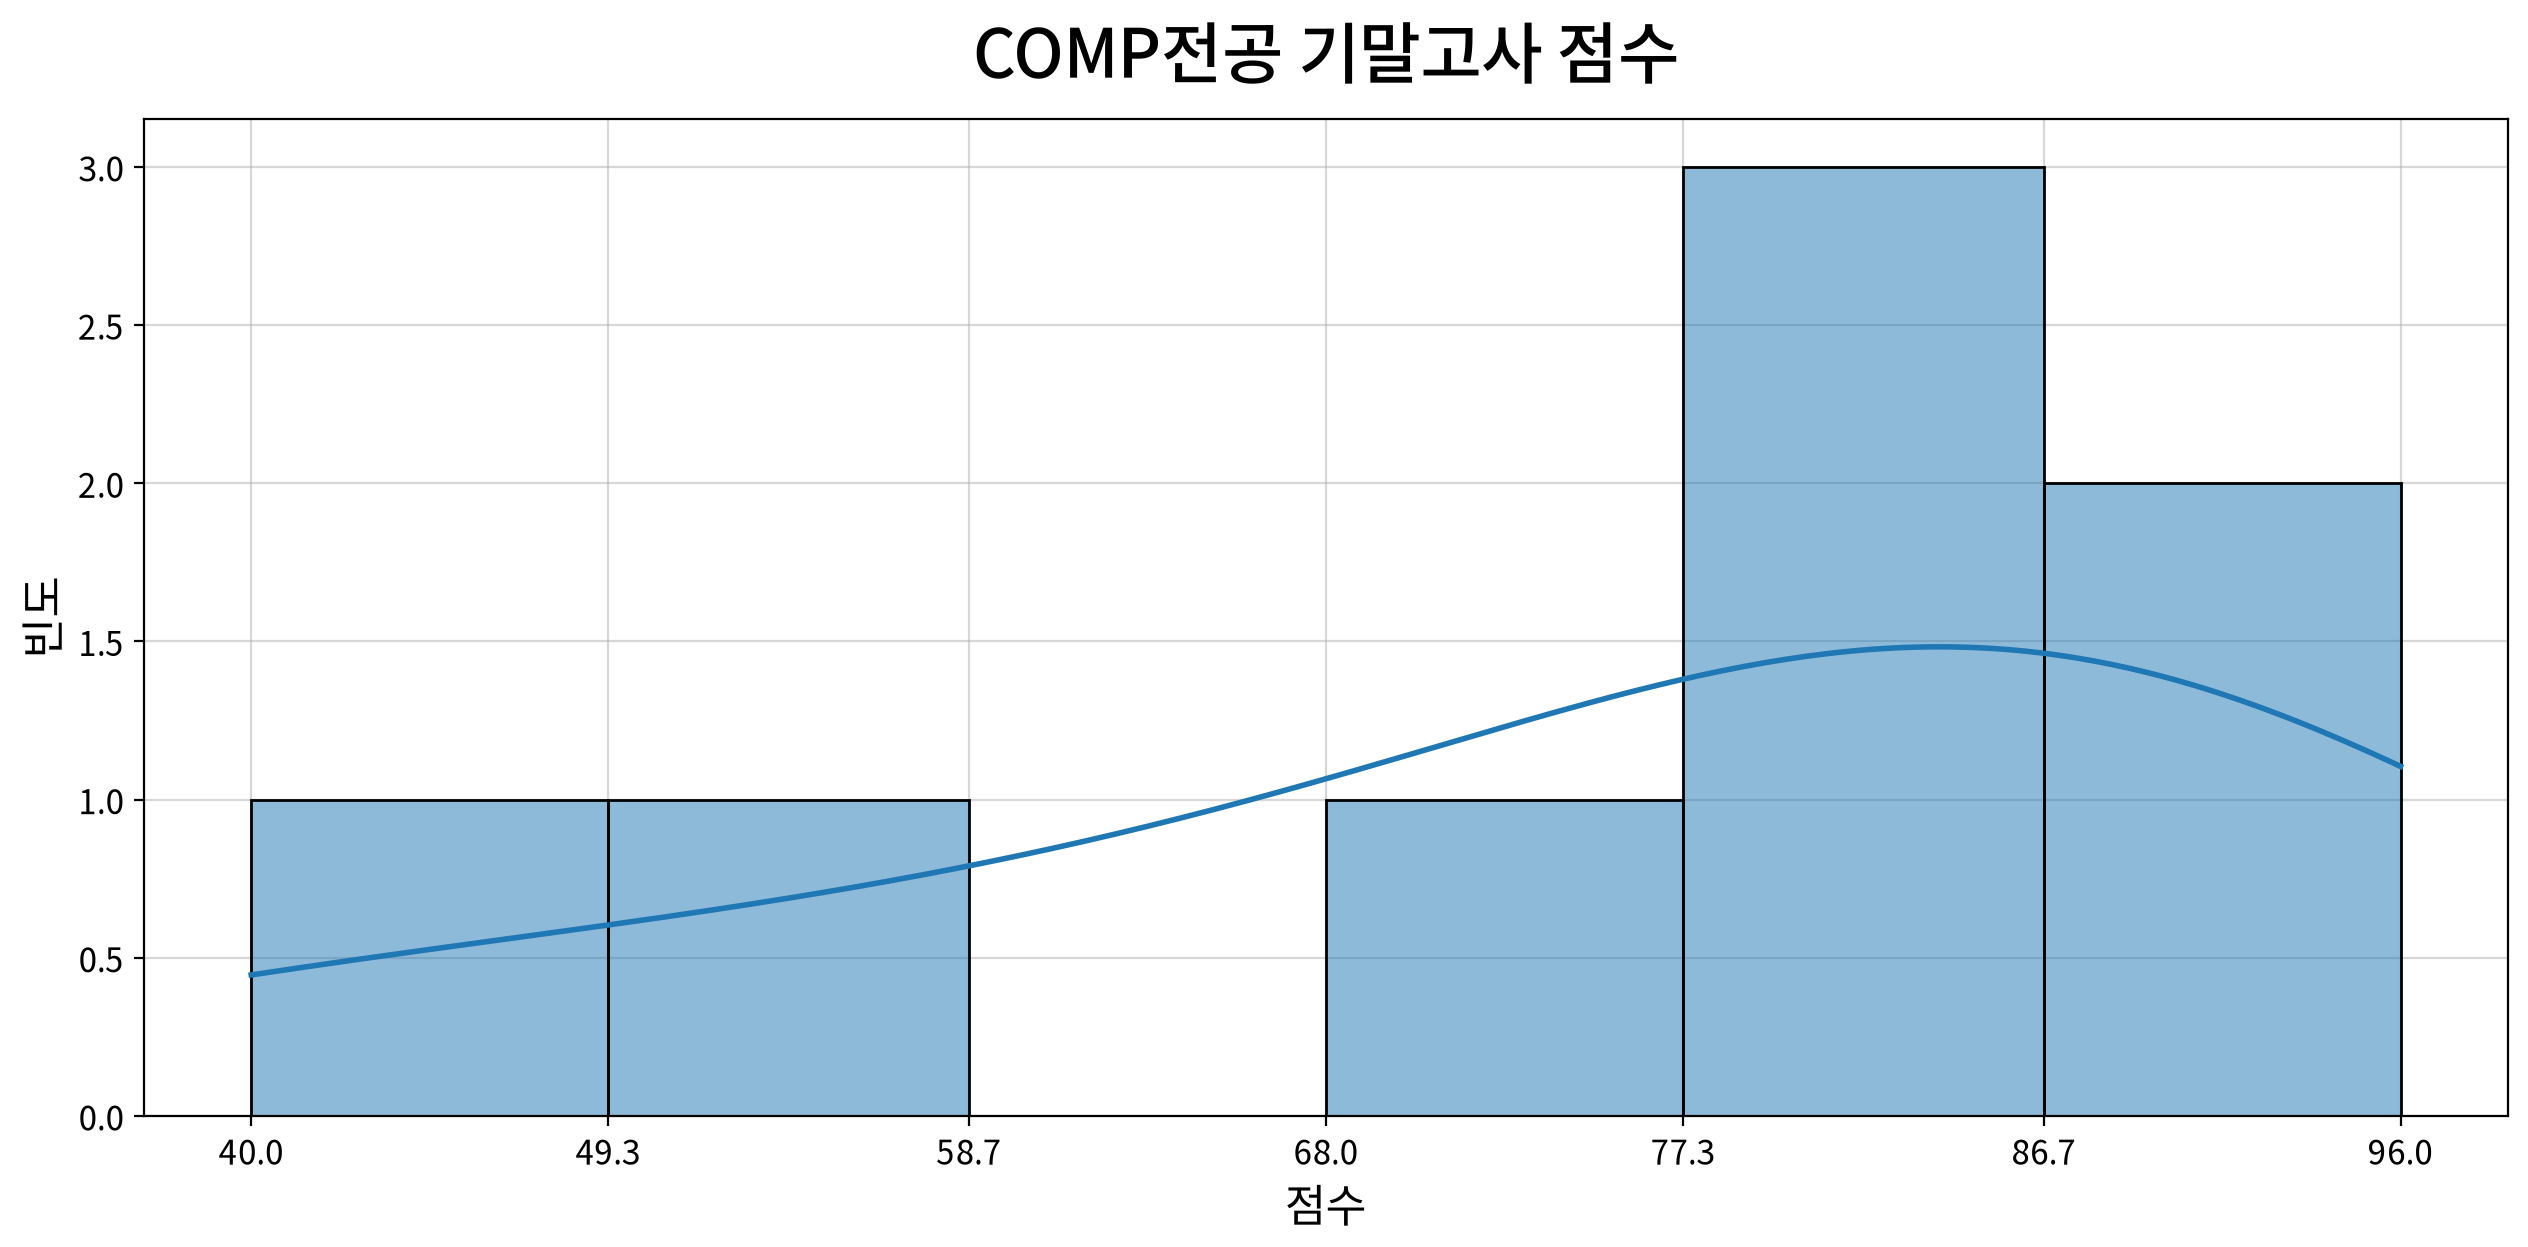

<Figure size 1280x960 with 0 Axes>

In [27]:
# 4. COMP전공 기말고사 점수
my_plot.histplot(data=stat_comp, title="COMP전공 기말고사 점수",x="기말고사", xlabel="점수", ylabel="빈도", kde=True, bins=6)
my_plot.show()

#### 문 제 1. 통계학 전공의 중간고사 점수 분포에 나타난 봉우리(peak)는 몇 개 인가?
##### 그래프 상의 50점대와 80점대에 봉우리가 두개가 나온다.
#### 문 제 2. 통계학 전공의 중간고사 분포에서 학생 수가 0명인 점수 구간은 약 몇 점대인가?
##### 54.0점 ~ 64.0점구간에 0명이 분포가 되어있다.
#### 문 제 3. 통계학 전공 학생들의 기말고사에서 가장 많은 학생이 분포한 점수 구간은?
##### 74.0 ~ 81.0, 81.0 ~ 88.0 점대에서 가장 많은 학생이 분포가 되어있다.
#### 문 제 4. 전산학 전공의 기말고사 점수 분포의 왜도 방향은? (양/음 중 택1)
##### 그래프 상으로 오른쪽에 몰려있어 음의 왜도가 나온다.
#### 문 제 5. 두 전공의 중간고사와 기말고사를 비교했을 때, 학생들의 점수는 전반적으로 (높아졌다 / 낮아졌다)중 어느 쪽인가?
##### 두전공 모두 다 중간고사보다 기말고사 점수가 전반적으로 높아졌다.
##### 이유는 통계학 최저값 (34.0 -> 53.0) 전산학 최저값 (31.0 -> 40.0)이 높아지고 최고값은 통계학 94.0 -> 95.0, 전산학은 87.0 -> 96.0으로 높아짐.

